<a href="https://colab.research.google.com/github/gustianmajs/052842605-Gustian-Machine-Learning-STIK4481/blob/main/052842605_Gustian_Machine_Learning_(STIK4481)_Tugas_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 1: Preprocessing Dataset Mahasiswa

Di sini saya akan melakukan langkah-langkah preprocessing data sesuai dengan petunjuk pengerjaan Tugas 1 untuk mata kuliah Machine Learning.

## Tahap 1: Load Dataset

Langkah awal adalah mengimpor semua library Python yang dibutuhkan dan membaca file dataset CSV ke dalam pandas DataFrame.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Import file dataset
file_path = '/content/drive/MyDrive/Universitas Terbuka/Semester 4/02 Machine Learning (STIK4481)/052842605 Gustian - Machine Learning (STIK4481) - Tugas 1/dataset_tugas1_preprocessing.csv'

# Load data
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama data
display(df.head())

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


## Tahap 2: Eksplorasi Awal (EDA)

Sebelum melakukan manipulasi data, saya akan mengecek tipe data, jumlah nilai kosong (null/missing values) di setiap kolom, serta statistik dasarnya terlebih dahulu.

In [ ]:
# Cek info umum dan tipe data tiap kolom
print("=== Struktur dan Tipe Data ===")
df.info()

# Cek apakah ada kolom yang datanya kosong/null
print("\n=== Jumlah Nilai Hilang per Kolom ===")
display(df.isnull().sum())

# Tampilkan ringkasan statistik deskriptif untuk data angka maupun teks
print("\n=== Statistik Deskriptif (Numerik & Kategorikal) ===")
display(df.describe(include='all'))

=== Struktur dan Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB

=== Jumlah Nilai Hilang per Kolom ===


,0
ID,0
Nama,0
Jenis_Kelamin,0
Prodi,0
Status,0
Nilai_Akhir,29
Tanggal_Ujian,0
Umur,9



=== Statistik Deskriptif (Numerik & Kategorikal) ===


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
count,99,99,99,99,99,70,99,90.000000
unique,99,10,2,4,4,5,97,NaN
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/03/31,NaN
freq,1,15,50,28,29,17,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.366667
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.763963
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000


## Tahap 3: Menangani Missing Values

Dari hasil EDA di atas, terlihat ada data kosong pada kolom `Umur` dan `Nilai_Akhir`.
- Untuk kolom `Umur` (numerik), saya akan mengisi data yang kosong menggunakan nilai tengah (median).
- Untuk kolom `Nilai_Akhir` (kategorikal/teks), saya akan mengisinya dengan nilai yang paling sering muncul (modus).

In [ ]:
# Isi nilai kosong pada Umur dengan nilai median
if 'Umur' in df.columns:
    df['Umur'] = df['Umur'].fillna(df['Umur'].median())

# Isi nilai kosong pada Nilai_Akhir dengan modus data tersebut
if 'Nilai_Akhir' in df.columns:
    if df['Nilai_Akhir'].dtype == 'object':
        df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])
    else:
        df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].median())

# Pastikan kembali sudah tidak ada lagi data yang kosong di kedua kolom tersebut
print("Jumlah missing values setelah diisi:")
print(df[['Umur', 'Nilai_Akhir']].isnull().sum())

# Tampilkan sampel data terbaru
display(df.head())

Jumlah missing values setelah imputasi:
Umur           0
Nilai_Akhir    0
dtype: int64


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,8,0,3,0,2,2020-04-13,23.0
1,MH002,4,1,3,3,4,2020-12-11,28.0
2,MH003,8,0,3,0,2,2021-11-21,23.0
3,MH004,4,1,3,0,3,2021-08-19,18.0
4,MH005,9,1,0,0,2,2020-01-05,26.0


## Tahap 4: Normalisasi Format Tanggal

Format tanggal pada kolom `Tanggal_Ujian` masih tidak seragam. Saya akan mengubah tipe datanya menjadi format datetime standar.

In [ ]:
# Load ulang data tanggal dari file asli agar bersih dari konversi sebelumnya, lalu ubah ke format datetime
df_raw = pd.read_csv(file_path)
if 'Tanggal_Ujian' in df.columns:
    df['Tanggal_Ujian'] = pd.to_datetime(df_raw['Tanggal_Ujian'], format='mixed', errors='coerce')

# Cek tipe data baru dan pastikan tidak ada nilai NaT/null setelah konversi
print("Tipe data kolom Tanggal_Ujian:")
print(df['Tanggal_Ujian'].dtype)
print("\nJumlah missing values pada Tanggal_Ujian:", df['Tanggal_Ujian'].isnull().sum())
display(df[['Tanggal_Ujian']].head(10))

Tipe data kolom Tanggal_Ujian setelah konversi:
datetime64[ns]

Jumlah missing values pada Tanggal_Ujian (setelah perbaikan): 0


,Tanggal_Ujian
0,2020-04-13
1,2020-12-11
2,2021-11-21
3,2021-08-19
4,2020-01-05
5,2021-10-15
6,2020-01-15
7,2020-09-16
8,2021-02-06
9,2020-02-12


## Tahap 5: Encoding Label

Beberapa kolom kategorikal seperti Nama, Jenis Kelamin, Prodi, Status, dan Nilai Akhir harus diubah ke bentuk angka (Label Encoding) agar bisa dipahami oleh algoritma machine learning nantinya.

In [ ]:
# Tentukan kolom-kolom kategorikal yang mau dikonversi ke angka
cols_to_encode = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']
le = LabelEncoder()

for col in cols_to_encode:
    if col in df.columns:
        # Konversi dulu ke tipe string untuk menghindari masalah tipe data campuran sebelum fit_transform
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])

# Tampilkan hasil dataframe setelah semua kolom kategorikal berubah menjadi angka
print("Dataframe setelah proses Label Encoding:")
display(df.head())

Dataframe setelah proses Encoding:


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,8,0,3,0,2,2020-04-13,23.0
1,MH002,4,1,3,3,4,2020-12-11,28.0
2,MH003,8,0,3,0,2,2021-11-21,23.0
3,MH004,4,1,3,0,3,2021-08-19,18.0
4,MH005,9,1,0,0,2,2020-01-05,26.0


## Tahap 6: Split Data

Sekarang saya akan memisahkan seluruh dataset ini menjadi data latih (train set) sebesar 80% dan data uji (test set) sebesar 20%.

In [ ]:
# Bagi dataset menjadi 80% data training dan 20% data testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {len(train_df)} baris")
print(f"Jumlah data uji: {len(test_df)} baris")
print("\nContoh data latih:")
display(train_df.head())

Jumlah data latih setelah perbaikan tanggal: 79 baris
Jumlah data uji setelah perbaikan tanggal: 20 baris

Sampel data latih (termasuk Tanggal_Ujian):


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
49,MH050,4,1,1,2,2,2021-10-01,21.0
70,MH071,5,0,1,2,2,2021-08-15,19.0
68,MH069,7,1,1,1,1,2022-01-21,24.0
15,MH016,4,0,2,3,4,2020-02-11,19.0
39,MH040,2,0,1,1,2,2022-03-21,29.0


## Tahap 7: Visualisasi Data

Untuk mendapatkan gambaran yang jelas, saya akan membuat visualisasi berupa histogram untuk melihat persebaran umur mahasiswa dan bar chart untuk mengetahui jumlah mahasiswa di setiap program studi.

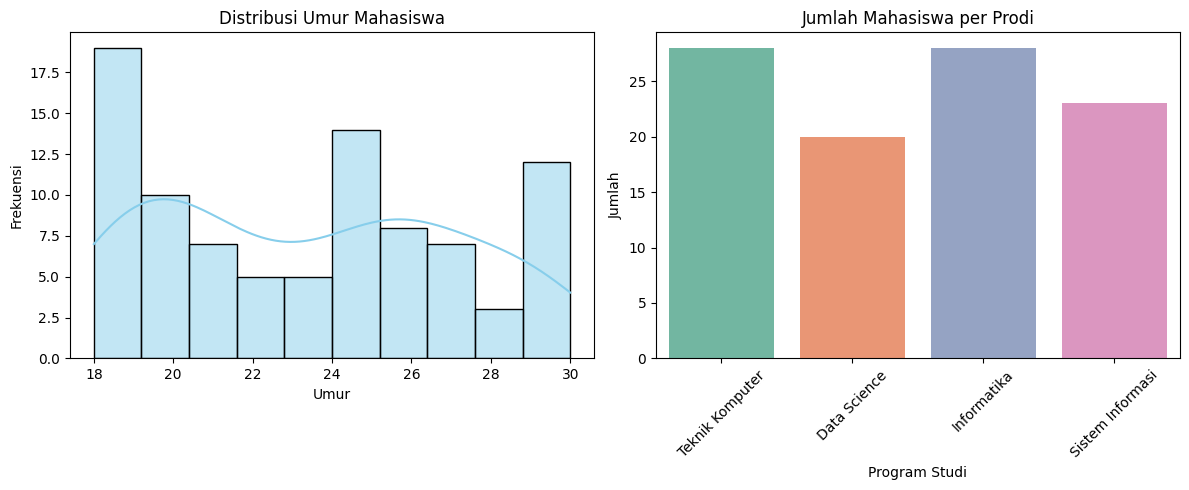

In [ ]:
# Load ulang data original untuk visualisasi agar teks label Prodi lebih mudah dibaca
df_orig = pd.read_csv(file_path)

plt.figure(figsize=(12, 5))

# Plot 1: Histogram Umur
plt.subplot(1, 2, 1)
sns.histplot(df_orig['Umur'].dropna(), bins=10, kde=True, color='skyblue')
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Jumlah Frekuensi')

# Plot 2: Bar Chart Jumlah Mahasiswa per Prodi
plt.subplot(1, 2, 2)
sns.countplot(data=df_orig, x='Prodi', hue='Prodi', palette='Set2', legend=False)
plt.title('Jumlah Mahasiswa per Prodi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()